In [36]:
from torchvision.io import decode_image, read_file
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt
import json
import torch.nn.functional as F

In [2]:
jsonPath = r"C:\Users\adria\Desktop\Python\Machine-learning\data\imagenet_class_index.json"
image_paths = [
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\348_rock-ptarmigan_fjallripa_lagopus-muta-muta_stekenjokk-jamtland_20110711_1_1000n-336891473.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\blacktail6-2433556291.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\great+white+shark2-494833641.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\OIP-1306616460.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\OIP-2531215737.jpg"
]

In [66]:
def get_model_and_weights(mod="resnet18"):
    weights = get_model_weights(mod).DEFAULT
    model = get_model(mod, weights=weights).eval()
    return model, weights

def image_preprocess(img_path, weights):
    img_bytes = read_file(img_path)
    img = decode_image(img_bytes)
    
    preprocess = weights.transforms()

    return img, preprocess(img)

def get_activation_map(input_tensor, model, layer="layer4"):
    cam_extractor = LayerCAM(model, target_layer=layer)
    out = model(input_tensor.unsqueeze(0))
    return cam_extractor(out.squeeze(0).argmax().item(), out)

def normalize_and_resize_cam(activation_map, pil_image):
    activation_map = activation_map[0]
    cam = activation_map.squeeze(0)

    if cam.ndim == 3:
        cam = cam.squeeze(0)

    cam = cam - cam.min()
    cam = cam / cam.max()

    cam_resized = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=pil_image.size[::-1],
        mode="bilinear",
        align_corners=False
    ).squeeze()

    cam_np = cam_resized.cpu().numpy()

    pil_activation_map = to_pil_image(cam_resized, mode="F")

    return cam_np, pil_activation_map


def get_pred(input_tensor, model):
    logits = model(input_tensor.unsqueeze(0))
    preds = logits.softmax(dim=1)
    return preds.squeeze(0).detach()

def predict_class(output_tensor, class_indx_path):
    with open(class_indx_path, "r") as file:
        class_index = json.load(file)
    
    probs = output_tensor.squeeze()

    top_index = int(probs.argmax())

    synset_id, class_name = class_index[str(top_index)]

    return {
        "class index" : top_index,
        "class id" : synset_id,
        "class name" : class_name,
        "confidence" : float(probs[top_index])
    }

def plot_cam(image_paths, model, weights):
    n = len(image_paths)
    fig, ax = plt.subplots(n, 3, figsize=(9, 15))

    for j in range(n):
        image, input_tensor = image_preprocess(image_paths[j], weights)

        activation_map = get_activation_map(input_tensor, model)

        pil_image = to_pil_image(image)

        cam_np, pil_activation_map = normalize_and_resize_cam(activation_map, pil_image)
        
        overlay = overlay_mask(pil_image, pil_activation_map, alpha=0.5)
        
        ax[j][0].imshow(pil_image)
        ax[j][1].imshow(cam_np, cmap="jet")
        ax[j][2].imshow(overlay)

        titles = ["Original", "activation map", "overlay"]

        for i in range(3):
            ax[j][i].axis("off")
            ax[j][i].set_title(f"{titles[i]} image nr.{j}")
    plt.tight_layout()
    plt.show()

def print_prediction(input_tensor, model, jsonPath):
    pred = get_pred(input_tensor, model)
    prediction = predict_class(pred, jsonPath)

    for key, value in prediction.items():
        print(f"{key} : {value}")

activation_map shape: torch.Size([7, 7])
min: 0.0
max: 1.0
mean: 0.3302004933357239


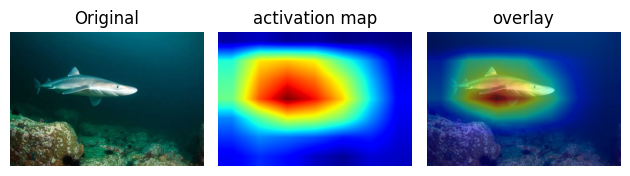

In [49]:
model, weights = get_model_and_weights()

image, input_tensor = image_prerocess(image_paths[4], weights)

activation_map = get_activation_map(input_tensor, model)
activation_map = activation_map[0]

#felsökning
print("activation_map shape:", activation_map.shape)
print("min:", activation_map.min().item())
print("max:", activation_map.max().item())
print("mean:", activation_map.mean().item())


#normalize activation map
cam = activation_map.squeeze(0)

if cam.ndim == 3:
    cam = cam.squeeze(0)

cam = cam - cam.min()
cam = cam / cam.max()

pil_image = to_pil_image(image)

cam_resized = F.interpolate(
    cam.unsqueeze(0).unsqueeze(0),
    size=pil_image.size[::-1],
    mode="bilinear",
    align_corners=False
).squeeze()

cam_np = cam_resized.cpu().numpy()

pil_activation_map = to_pil_image(cam_resized, mode="F")

overlay = overlay_mask(pil_image, pil_activation_map, alpha=0.5)

fig, ax = plt.subplots(1, 3)
ax[0].imshow(pil_image)
ax[1].imshow(cam_np, cmap="jet")
ax[2].imshow(overlay)

titles = ["Original", "activation map", "overlay"]

for i in range(3):
    ax[i].axis("off")
    ax[i].set_title(titles[i])
plt.tight_layout()
plt.show()

In [ ]:
def print_prediction(input_tensor, model, jsonPath):
    pred = get_pred(input_tensor, model)
    prediction = predict_class(pred, jsonPath)

    for key, value in prediction.items():
        print(f"{key} : {value}")

class index : 3
class id : n01491361
class name : tiger_shark
confidence : 0.48420557379722595


In [ ]:
for imgPath in image_paths:
    image, input_tensor = image_prerocess(image_paths[i], weights)

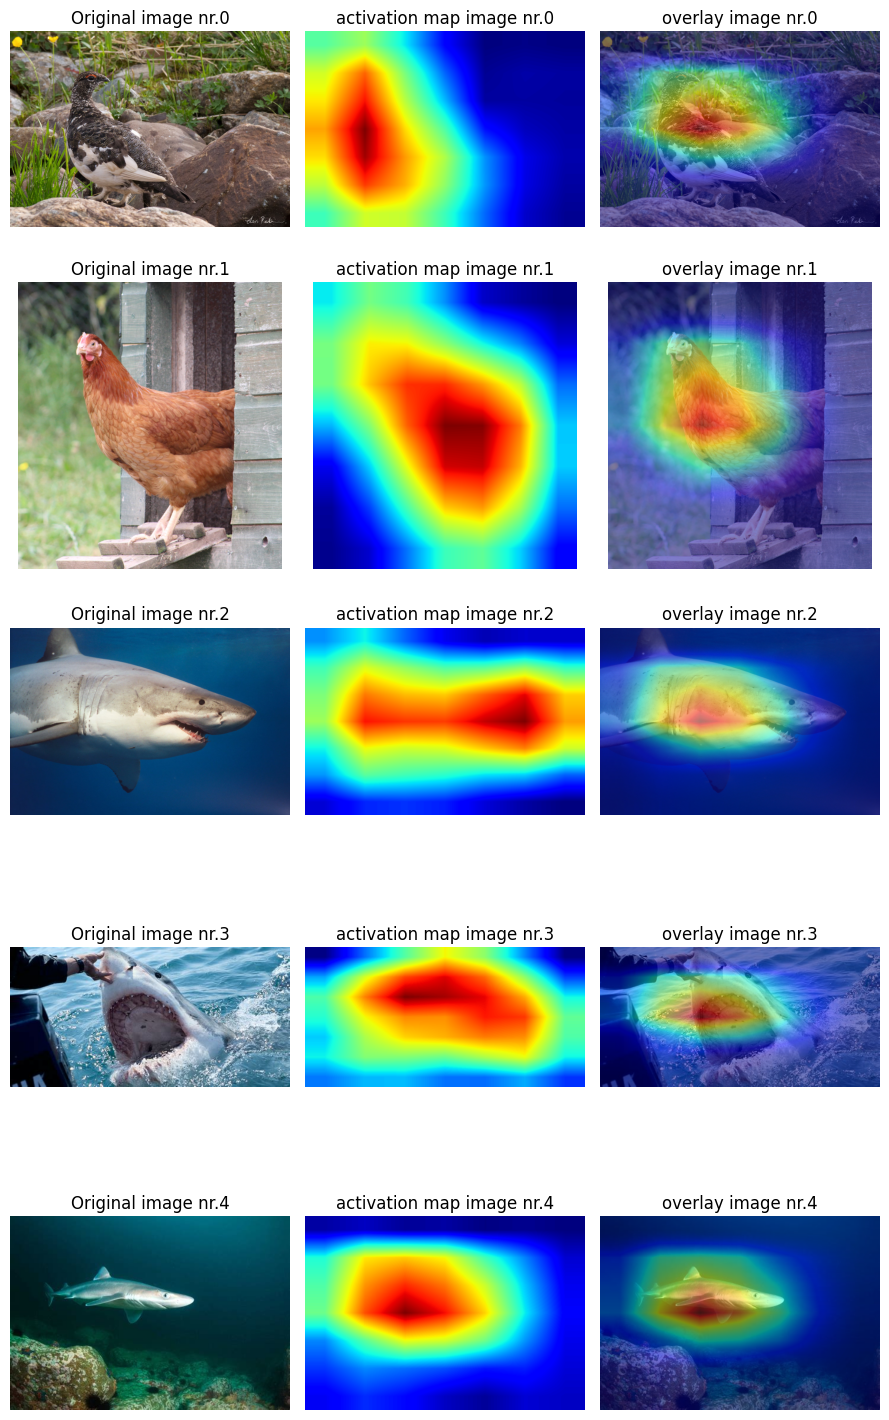

In [ ]:
def plot_cam(image_paths, model, weights):
    n = len(image_paths)
    fig, ax = plt.subplots(n, 3, figsize=(9, 15))

    for j in range(n):
        image, input_tensor = image_prerocess(image_paths[j], weights)

        activation_map = get_activation_map(input_tensor, model)

        pil_image = to_pil_image(image)

        cam_np, cam_resized, activation_map = normalize_and_resize_cam(activation_map, pil_image)
        
        overlay = overlay_mask(pil_image, pil_activation_map, alpha=0.5)
        
        ax[j][0].imshow(pil_image)
        ax[j][1].imshow(cam_np, cmap="jet")
        ax[j][2].imshow(overlay)

        titles = ["Original", "activation map", "overlay"]

        for i in range(3):
            ax[j][i].axis("off")
            ax[j][i].set_title(f"{titles[i]} image nr.{j}")
    plt.tight_layout()
    plt.show()
    

In [ ]:
def plot_layers(image_path, model, weights, layers=["layer1", "layer2", "layer3", "layer4"]):
    image, input_tensor = image_preprocess(image_path, weights)
    pil_image = to_pil_image(image)

    n = len(layers)
    fig, ax = plt.subplots(1, n, figsize=(15, 5))

    ax[0].imshow(pil_image)
    ax[0].set_title("Original")
    ax[0].axis("off")

    for i, layer in enumerate(layers):
        activation_map = get_activation_map(input_tensor, model, layer=layer)
        pil_activation_map = normalize_and_resize_cam(activation_map, pil_image)[1]
        overlay = overlay_mask(pil_image, pil_activation_map, alpha=0.5)
        ax[i+1].imshow(overlay, cmap="jet")
        ax[i+1].set_title(layer)
        ax[i+1].axis("off")
        


5